In [1]:
from matplotlib import pyplot as plt
import scipy as sp
import numpy as np

from math import exp
from math import factorial as fac

In [2]:
N_ = 435
N_g_ = 600
R = 0.00888
K = 0.00772
Dt = 0.05

In [3]:
def poissonEat(x, N, N_g):
    if x < 0:
        return 0
    else:
        return (N*R*N_g/1000*Dt)**x * exp(-N*R*N_g/1000*Dt) / fac(x)

In [4]:
def poissonReg(x, N_g):
    if x < 0:
        return 0
    else:
        return (K*N_g*(1-N_g/1000)*Dt)**x * exp(-K*N_g*(1-N_g/1000)*Dt) / fac(x)

In [5]:
def conv(x, N, N_g):
    return sum([
        poissonEat(i, N, N_g)*poissonReg(i+x, N_g) for i in range(-100, 100)
    ])

In [6]:
def convE(N, N_g):
    #expected value of convolved distributions
    return np.sum(np.array([conv(i, N, N_g) for i in range(-10, 10)])*np.arange(-10,10))

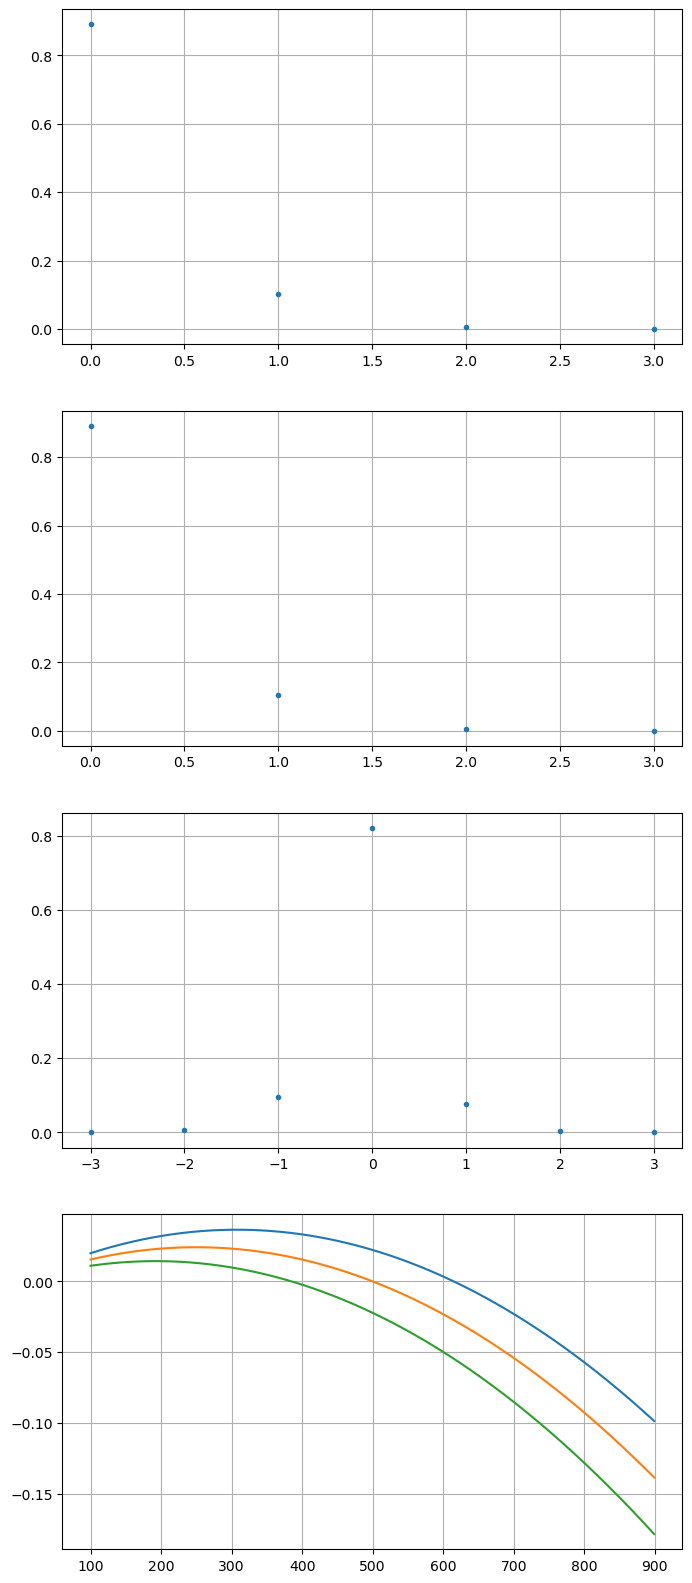

In [8]:
f, axs = plt.subplots(nrows=4, figsize=(8, 20))

axs[0].plot([i for i in range(0, 4)], [poissonEat(i, N_, N_g_) for i in range(0, 4)], ".")

axs[1].plot([i for i in range(0, 4)], [poissonEat(i, N_, N_g_) for i in range(0, 4)], ".")

axs[2].plot([i for i in range(-3, 4)], [conv(i, N_, N_g_) for i in range(-3, 4)], ".")

axs[3].plot(np.arange(100, 900), [convE(335, i) for i in range(100, 900)])
axs[3].plot(np.arange(100, 900), [convE(435, i) for i in range(100, 900)])
axs[3].plot(np.arange(100, 900), [convE(535, i) for i in range(100, 900)])

for i in axs:
    i.grid(True)

plt.show()